In [2]:
%%capture  # supress output
!pip install fastai
!pip install ipywidgets


UsageError: unrecognized arguments: supress output


In [3]:
from ipywidgets import interact
from fastai.basics import *

# defining runtime config of plots (figure in our case)
plt.rc("figure", dpi=90)

In [4]:
def plot_funciton(f, title=None, min=-2.1, max=2.1, color="r", ylim=None):
    x = torch.linspace(min, max, 100)[:, None]
    if ylim:
        plt.ylim(ylim)
    plt.plot(x, f(x), color)
    if title is not None:
        plt.title(title)

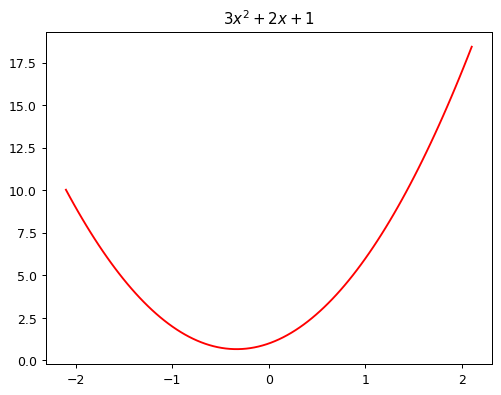

In [5]:
def f(x):
    return 3 * x**2 + 2 * x + 1


plot_funciton(f, "$3x^2+2x+1$")

Make a quadratic function

In [6]:
def quad(a, b, c, x):
    return a * x**2 + b * x + c

Make the quadtratic function dynamic

In [7]:
def mk_quad(a, b, c):
    return partial(quad, a, b, c)

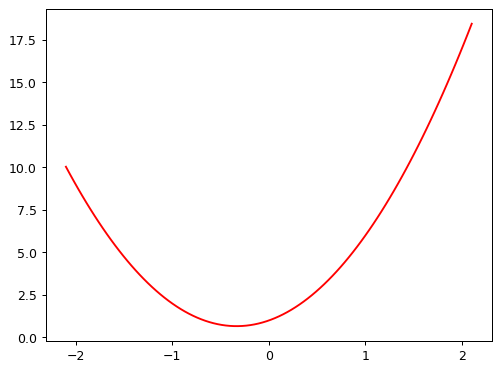

In [8]:
f2 = mk_quad(3, 2, 1)
plot_funciton(f2)  # values of x are defined in he plot_fucntion

create function for adding noise

In [9]:
def noise(x, scale):
    return np.random.normal(scale=scale, size=x.shape)


def add_noise(x, mult, add):
    return x * (1 + noise(x, mult)) + noise(x, add)

In [27]:
np.random.seed(42)
x = torch.linspace(-2.1, 2.1, steps=20)[:, None]
y = add_noise(f(x), 0.15, 1.5)

/tmp/ipykernel_4072921/1945435617.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return x * (1 + noise(x, mult)) + noise(x, add)


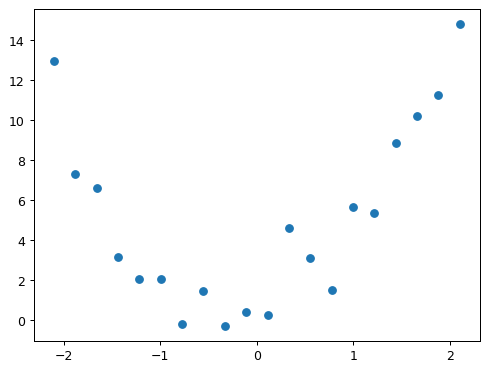

In [28]:
plt.scatter(x, y)

In [ ]:
@interact(a=1.1, b=1.1, c=1.1)
def plot_quad(a, b, c):
    plt.scatter(x, y)
    plot_funciton(mk_quad(a, b, c), ylim=(-1, 15))

interactive(children=(FloatSlider(value=1.1, description='a', max=3.3000000000000003, min=-1.1), FloatSlider(v…

In [42]:
def mae(preds,acts): return torch.abs(preds-acts).mean()

In [43]:
@interact(a=1.1, b=1.1, c=1.1)
def plot_quad(a, b, c):
    f = mk_quad(a,b,c)
    plt.scatter(x,y)
    loss = mae(f(x), y)
    plot_funciton(f, ylim=(-3,12), title=f"MAE: {loss:.2f}")

interactive(children=(FloatSlider(value=1.1, description='a', max=3.3000000000000003, min=-1.1), FloatSlider(v…